--- Optimization Results (500000 Evaluations | Pop Size: 500) ---
GD:  0.0160
IGD: 0.0123
HV:  0.9756
Pareto Points: 500/500000 (0.10%)
Generalized Spread (Lambda): 0.4876


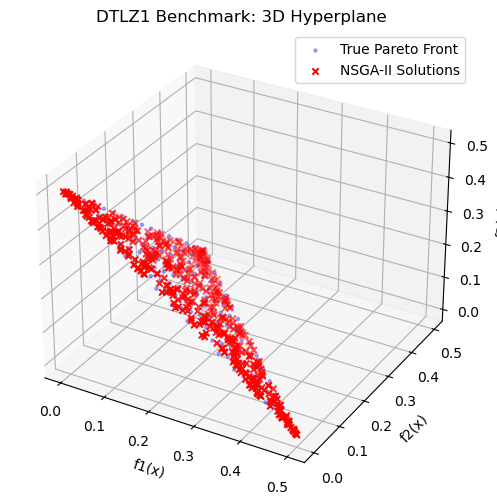

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.optimize import minimize
from pymoo.indicators.gd import GD
from pymoo.indicators.igd import IGD
from pymoo.indicators.hv import HV
from pymoo.problems import get_problem

# Experiment Parameters
pop_size = 500
n_gen = 1000
total_evals = pop_size * n_gen 

# DTLZ1 Problem (7 Variables, 3 Objectives)
class DTLZ1(Problem):
    def __init__(self):
        super().__init__(n_var=7, n_obj=3, xl=[0.0]*7, xu=[1.0]*7)

    def _evaluate(self, x, out, *args, **kwargs):
        # The last 5 variables form the distance-controlling set
        X_M = x[:, 2:]
        
        # Calculate g(x) landscape with local optima
        g = 100 * (5 + np.sum((X_M - 0.5)**2 - np.cos(20 * np.pi * (X_M - 0.5)), axis=1))
        
        # Calculate 3 Objective Functions
        f1 = 0.5 * x[:, 0] * x[:, 1] * (1 + g)
        f2 = 0.5 * x[:, 0] * (1 - x[:, 1]) * (1 + g)
        f3 = 0.5 * (1 - x[:, 0]) * (1 + g)
        
        out["F"] = np.column_stack([f1, f2, f3])

# Run NSGA-II
res = minimize(DTLZ1(), NSGA2(pop_size=pop_size), ('n_gen', n_gen), seed=42, verbose=False)

# Fetch True Pareto Front directly from pymoo
pf_true = get_problem("dtlz1").pareto_front()

# Quality Indicators and 3D Visualization
if res.F is not None:
    print(f"--- Optimization Results ({total_evals} Evaluations | Pop Size: {pop_size}) ---")
    print(f"GD:  {GD(pf_true)(res.F):.4f}")
    print(f"IGD: {IGD(pf_true)(res.F):.4f}")
    
    # Reference point set to [1.0, 1.0, 1.0] for the 3 objectives
    print(f"HV:  {HV(ref_point=np.array([1.0, 1.0, 1.0]))(res.F):.4f}")
    print(f"Pareto Points: {len(res.F)}/{total_evals} ({(len(res.F) / total_evals) * 100:.2f}%)")

    # Generalized Spread (Lambda) Calculation
    F = res.F
    if len(F) < 2:
        print("Generalized Spread (Lambda): N/A (insufficient Pareto points)")
    else:
        D = cdist(F, F)
        np.fill_diagonal(D, np.inf) 
        d_i = np.min(D, axis=1)
        d_bar = d_i.mean()
        
        # Extract the 3 extreme points of the True Front (one for each objective)
        E_true = np.array([pf_true[np.argmin(pf_true[:, i])] for i in range(3)])
        d_e = np.min(cdist(E_true, F), axis=1)
        
        sum_d_e = np.sum(d_e)
        lambda_spread = (sum_d_e + np.sum(np.abs(d_i - d_bar))) / (sum_d_e + len(F) * d_bar)
        print(f"Generalized Spread (Lambda): {lambda_spread:.4f}")

    # 3D Visualization
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(pf_true[:, 0], pf_true[:, 1], pf_true[:, 2], label="True Pareto Front", color="blue", s=5, alpha=0.3)
    ax.scatter(res.F[:, 0], res.F[:, 1], res.F[:, 2], label="NSGA-II Solutions", color="red", marker="x")
    
    ax.set_title("DTLZ1 Benchmark: 3D Hyperplane")
    ax.set_xlabel("f1(x)")
    ax.set_ylabel("f2(x)")
    ax.set_zlabel("f3(x)")
    ax.legend()
    plt.show()
else:
    print("No feasible solutions found.")